In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
# Modeling 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor 
from sklearn.svm import SVR 
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error 
from sklearn.model_selection import RandomizedSearchCV 
from catboost import CatBoostRegressor 
from xgboost import XGBRegressor 
import warnings 


### Import the CSV Datat as Pandas dataFrame 

In [2]:
df = pd.read_csv('stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Preparing X and Y variables 

In [4]:
X = df.drop(columns=['math_score'])

In [5]:
y = df['math_score']

In [6]:
# Create Column Transformer with 3 types of transformers 

num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(exclude="object").columns

from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer 

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer , num_features),
    ]
)


In [7]:
X = preprocessor.fit_transform(X)


In [8]:
## searte dataset into traiun and test 

from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test = train_test_split(X , y , test_size = 0.2, random_state = 42)
X_train.shape , X_test.shape

((800, 151), (200, 151))

### Create an Evaluation Function to give all metrics after model Trainning 

In [9]:
def evaluate_model(true,predicted):
    mae= mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true,predicted)

    return mae , mse , rmse , r2_square

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso":Lasso(),
    "Ridge" : Ridge(),
    "KNeighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    " Random Forest Regressor ": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(verbose=False),
    "AdaBoostRegressor":AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model; 

    #Make predictions 
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Evaluate Train and Test datset 
    model_train_mae,model_train_rmse,model_train_r2,r2_square = evaluate_model(y_train , y_train_pred)

    model_test_mae , model_test_rsme , model_test_r2 ,r2_square = evaluate_model(y_test, y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])


    print('Model performance for Training set ')
    print("- Root Mean Squared Error : {:.4f}".format(model_train_rmse))
    print("-Mean Absolue Error : {:.4f}".format(model_train_mae))
    print("- R2 Score : {:.4f}".format(model_train_r2))


    print('---------------------------------------')

    print('Model performance for Test set ')
    print("- Root Mean Squared Error : {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print("="*40)
    print("\n")

Linear Regression
Model performance for Training set 
- Root Mean Squared Error : 61.3109
-Mean Absolue Error : 6.2872
- R2 Score : 7.8301
---------------------------------------
Model performance for Test set 
- Root Mean Squared Error : 7.9516
- R2 Score: 9.7757


Lasso
Model performance for Training set 
- Root Mean Squared Error : 75.3557
-Mean Absolue Error : 6.9821
- R2 Score : 8.6808
---------------------------------------
Model performance for Test set 
- Root Mean Squared Error : 7.3635
- R2 Score: 8.8751


Ridge
Model performance for Training set 
- Root Mean Squared Error : 61.9957
-Mean Absolue Error : 6.3800
- R2 Score : 7.8737
---------------------------------------
Model performance for Test set 
- Root Mean Squared Error : 7.6834
- R2 Score: 9.3038


KNeighbors Regressor
Model performance for Training set 
- Root Mean Squared Error : 56.1406
-Mean Absolue Error : 6.0245
- R2 Score : 7.4927
---------------------------------------
Model performance for Test set 
- Root Me

Results 

In [12]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
4,Decision Tree,12.027833
6,XGBRegressor,10.611248
5,Random Forest Regressor,10.246337
3,KNeighbors Regressor,9.956405
0,Linear Regression,9.775729
7,CatBoostRegressor,9.552252
2,Ridge,9.303775
8,AdaBoostRegressor,8.897187
1,Lasso,8.875116


## Linear Regression 

In [13]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 60.73


Plot y_pred and y_test 

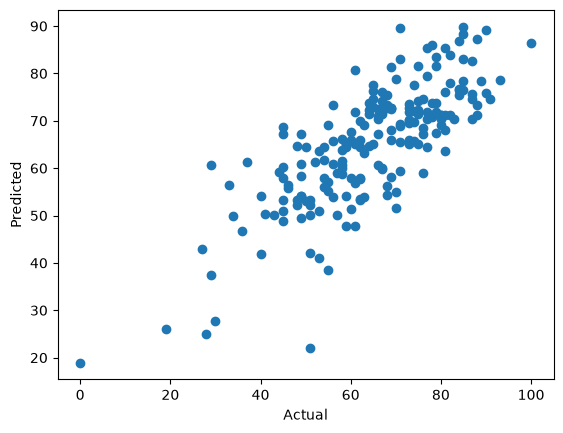

In [14]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

<Axes: xlabel='math_score'>

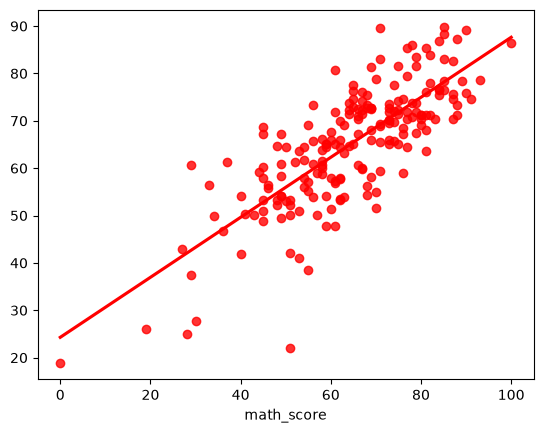

In [15]:
sns.regplot(x=y_test,y=y_pred,ci=None,color = 'red')

#### Difference bertween Actual and Predicted Values 

In [16]:
pred_df = pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,74.631496,16.368504
737,53,63.609891,-10.609891
740,80,70.367917,9.632083
660,74,69.817012,4.182988
411,84,75.491992,8.508008
...,...,...,...
408,52,61.257017,-9.257017
332,62,53.202379,8.797621
208,74,77.496735,-3.496735
613,65,72.962823,-7.962823
